In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [8]:
print("Duplicates:", train.duplicated().sum())
print("\nMissing values:")
print(train.isnull().sum())
print("\nData types:")
print(train.dtypes)

Duplicates: 0

Missing values:
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Data types:
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change    

In [9]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


***As you can see we need to check TyreLife cause The older the tires, the more likely a pit stop is coming!***

In [15]:
data = train.groupby('PitNextLap')['TyreLife'].mean()
print(data)

PitNextLap
0.0    12.822114
1.0    19.536873
Name: TyreLife, dtype: float64


***Tire gets older → performance drops → team decides to pit → fresh tires***

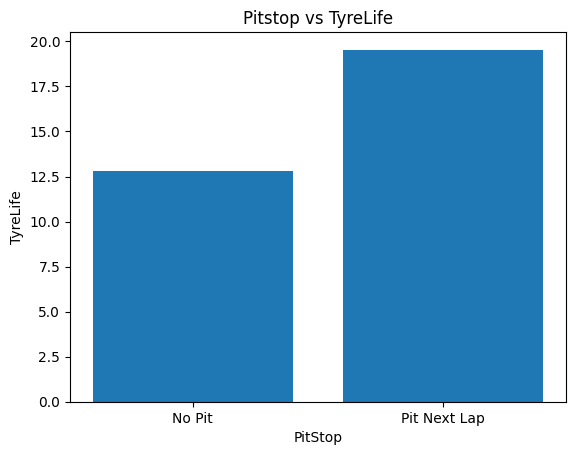

In [18]:
plt.bar(data.index, data.values)
plt.title('Pitstop vs TyreLife')
plt.xlabel('PitStop')
plt.ylabel('TyreLife')
plt.xticks([0.0, 1.0], ['No Pit', 'Pit Next Lap'])
plt.show()